# Estimate mesh error before using a result
### Richardson extrapolation and the grid convergence index

Estimate the mesh error of a slab centerline temperature using three systematically refined calculations. Richardson extrapolation assumes a leading error proportional to $h^p$; three meshes let you estimate $p$ instead of assuming it. The grid convergence index (GCI) applies a safety factor to the fine-grid difference, but it does not cover every modeling or input uncertainty. Examine its assumptions, especially for oscillatory convergence or coarse meshes. The smooth manufactured problem here supplies an exact check.

**Today's goal:** estimate the mesh error of the centerline temperature from three resolutions.

**Success criteria:** observed order between 1.9 and 2.1; extrapolated temperature rise within 0.001 K of the exact value; and a correctly labeled fine-grid error estimate. No earlier assignment is required.

**Time:** 40 minutes of practice and 25 minutes of reading. Run cells from top to bottom with NumPy, Matplotlib, and IPython.

**Notation:** $T_N$ is the numerical temperature field on an $N$-interval mesh. $f_N=T_N(L/2)-300\,\mathrm{K}$ is the computed centerline temperature rise; the exact rise is 10 K. Keep signed mesh differences for extrapolation and use absolute values for error magnitudes.

## 1. Governing equation and reference solution

**Educational steady slab:**

$$L=0.10\,\mathrm{m},\qquad k=10\,\mathrm{W\,m^{-1}\,K^{-1}},\qquad T(0)=T(L)=300\,\mathrm{K}.$$

There is no advection or radiation. Solve

$$-k\frac{d^2T}{dx^2}=q'''(x),\qquad 0<x<L,$$
$$q'''(x)=k(10\,\mathrm{K})\left(\frac{\pi}{L}\right)^2\sin\left(\frac{\pi x}{L}\right).$$

The manufactured exact solution is

$$T^*(x)=300\,\mathrm{K}+(10\,\mathrm{K})\sin\left(\frac{\pi x}{L}\right).$$

Use centered differences with $N=10,20,40$ equal intervals and NumPy's direct linear solve. Track the centerline temperature rise

$$f_N=T_N(L/2)-300\,\mathrm{K}.$$

**Modeling check:** sketch the equation and derive the dimensional source units and exact outward-flux balance. Explain why each even-interval mesh samples the same center location $x=L/2$.

### Worked source and flux balance

The source units are $(\mathrm{W\,m^{-1}\,K^{-1}})(\mathrm{K})(\mathrm{m^{-2}})=\mathrm{W\,m^{-3}}$. Fourier's law gives the axial flux $q_x''=-kT'$. At the left face the outward normal is $-1$, so the outward flux is $kT'(0)=k(10\,\mathrm{K})\pi/L$; at the right face it is $-kT'(L)$ with the same value. Therefore,

$$q_{\mathrm{out,left}}''+q_{\mathrm{out,right}}''
=\frac{2k(10\,\mathrm{K})\pi}{L}
=\int_0^L q'''(x)\,dx
=2000\pi\,\mathrm{W\,m^{-2}}.$$

Each even $N$ has an integer node index $i=N/2$, and $x_i=ih=(N/2)(L/N)=L/2$. No interpolation is needed to compare the same centerline quantity across meshes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

L = 0.10  # m
k = 10.0  # W/(m K)
T_LEFT = T_RIGHT = 300.0  # K
AMPLITUDE = 10.0  # K
MESHES = (10, 20, 40)  # equal intervals; all even so each includes x=L/2

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})


def exact_temperature(x):
    """Return the manufactured exact temperature in kelvin."""
    return T_LEFT + AMPLITUDE * np.sin(np.pi * x / L)


def source_term(x):
    """Return the volumetric heat-generation rate in W/m^3."""
    return k * AMPLITUDE * (np.pi / L)**2 * np.sin(np.pi * x / L)

## 2. Discretization and conditions

Use $N$ equal intervals, $N+1$ nodes, and $h=L/N$. At interior node $i$, centered differences give

$$-k\frac{T_{i-1}-2T_i+T_{i+1}}{h^2}=q'''(x_i).$$

Only the $N-1$ interior temperatures are unknown. The two endpoint temperatures are prescribed, so their stencil contributions move to the right-hand side of the interior system.

**Stencil ingredients:** the diagonal and adjacent entries of $A$, the source entries in $b$, and the first/last right-hand-side contributions from $T(0)$ and $T(L)$. Keep the $h^{-2}$ factor in the matrix consistent with the source scaling.

**Check:** verify the source units are $\mathrm{W\,m^{-3}}$ and show that the exact total outward heat flux equals $\int_0^Lq'''(x)\,dx$ per unit area.

### Assembled system

With conductivity retained in the matrix, $A_{ii}=2k/h^2$ and $A_{i,i\pm1}=-k/h^2$. The right-hand side begins with $b_i=q'''(x_i)$, then receives $kT(0)/h^2$ in its first entry and $kT(L)/h^2$ in its last entry. Consequently, both $AT$ and $b$ have units of $\mathrm{W\,m^{-3}}$. Omitting $k$ from the matrix while retaining it in the source would solve a differently scaled problem.

In [2]:
def solve(N):
    """Return nodal coordinates x and temperature T for N equal intervals."""
    if not isinstance(N, (int, np.integer)) or N < 2:
        raise ValueError("N must be an integer with at least two intervals.")
    h = L / N
    x = np.linspace(0.0, L, N + 1)
    interior_count = N - 1
    A = k * (2.0 * np.eye(interior_count)
             - np.eye(interior_count, k=1)
             - np.eye(interior_count, k=-1)) / h**2
    b = source_term(x[1:-1]).copy()
    b[0] += k * T_LEFT / h**2
    b[-1] += k * T_RIGHT / h**2
    T = np.empty(N + 1)
    T[0], T[-1] = T_LEFT, T_RIGHT
    T[1:-1] = np.linalg.solve(A, b)
    return x, T

## 3. Richardson extrapolation and error estimate

Assume the centerline result has a leading mesh error proportional to $h^p$. The refinement ratio is $r=2$. Use the three computed rises $f_{10},f_{20},f_{40}$ to estimate the observed order

$$p=\log_2\left|\frac{f_{10}-f_{20}}{f_{20}-f_{40}}\right|.$$

Preserve the sign of the fine-grid difference in the extrapolation:

$$f_{\mathrm{ext}}=f_{40}+\frac{f_{40}-f_{20}}{2^p-1}.$$

The requested fine-grid GCI estimate is

$$G=\frac{1.25|f_{40}-f_{20}|}{2^p-1},\qquad \frac{G}{|f_{40}|}\text{ is a fraction.}$$

Report $f_{\mathrm{ext}}$ and $G$ in kelvin, label $G$ as an estimated fine-grid error, and compare it with the exact fine-grid error $|f_{40}-10\,\mathrm{K}|$. Treat $G$ as a numerical estimate, not a guaranteed confidence interval.

**Calculation:** obtain the three quantities from the results below. Keep signed differences for $f_{\mathrm{ext}}$; use absolute values only where shown.

In [3]:
mesh_results = {}
for N in MESHES:
    x, T = solve(N)
    center_index = N // 2
    assert np.isclose(x[center_index], L / 2), "Mesh must include the slab center."
    f = T[center_index] - T_LEFT
    mesh_results[N] = {"h": L / N, "x": x, "T": T, "f": f}

f10, f20, f40 = (mesh_results[N]["f"] for N in MESHES)


r = 2.0
coarse_difference = f10 - f20
fine_difference = f20 - f40
if coarse_difference * fine_difference <= 0:
    raise ValueError("This estimate requires nonzero, monotonic mesh differences.")
p = np.log(abs(coarse_difference / fine_difference)) / np.log(r)
if not np.isfinite(p) or p <= 0:
    raise ValueError("A positive, finite observed order is required.")
f_ext = f40 + (f40 - f20) / (r**p - 1.0)
G = 1.25 * abs(f40 - f20) / (r**p - 1.0)
G_fraction = G / abs(f40)
fine_exact_error = abs(f40 - AMPLITUDE)

## 4. Results and convergence

Compare the centerline rise on all three meshes. Keep the mesh-spacing and temperature units visible, and distinguish the observed order, extrapolated rise, and GCI estimate in your report.

**Report:** a reproducible three-mesh table; $p$, $f_{\mathrm{ext}}$, $G$ in kelvin, and $G/|f_{40}|$ as a fraction; plus two sentences describing limitations of the GCI estimate.

**Check:** observed order in $[1.9,2.1]$, extrapolated rise within 0.001 K of 10 K, and compare the estimated $G$ with the exact fine-grid error.

In [4]:
table = [
    "| Intervals N | Spacing h (m) | Centerline rise f_N (K) | Exact error (K) |",
    "|---:|---:|---:|---:|",
]
for N in MESHES:
    row = mesh_results[N]
    exact_error = abs(row["f"] - AMPLITUDE)
    table.append(
        f"| {N} | {row['h']:.5f} | {row['f']:.8f} | {exact_error:.3e} |"
    )
display(Markdown("\n".join(table)))


display(Markdown(
    f"**Observed order:** {p:.6f}  \n"
    f"**Extrapolated centerline rise:** {f_ext:.8f} K  \n"
    f"**Estimated fine-grid error (GCI with safety factor 1.25):** {G:.8f} K  \n"
    f"**Relative GCI, normalized by temperature rise:** {G_fraction:.8f} "
    f"(fraction), or {100 * G_fraction:.4f}%  \n"
    f"**Exact fine-grid error:** {fine_exact_error:.8f} K  \n"
    f"**Estimate / exact error:** {G / fine_exact_error:.4f}  \n"
    f"**Extrapolation error:** {abs(f_ext - AMPLITUDE):.3e} K"
))

| Intervals N | Spacing h (m) | Centerline rise f_N (K) | Exact error (K) |
|---:|---:|---:|---:|
| 10 | 0.01000 | 10.08265417 | 8.265e-02 |
| 20 | 0.00500 | 10.02058707 | 2.059e-02 |
| 40 | 0.00250 | 10.00514200 | 5.142e-03 |

**Observed order:** 2.006683  
**Extrapolated centerline rise:** 10.00002533 K  
**Estimated fine-grid error (GCI with safety factor 1.25):** 0.00639585 K  
**Relative GCI, normalized by temperature rise:** 0.00063926 (fraction), or 0.0639%  
**Exact fine-grid error:** 0.00514200 K  
**Estimate / exact error:** 1.2438  
**Extrapolation error:** 2.533e-05 K

## 5. Solution and diagnostic plots

Plot the three numerical temperature fields together with the analytic solution. Add a second panel for the pointwise error $T_N-T^*$ so mesh differences remain visible even when the temperature curves nearly overlap.

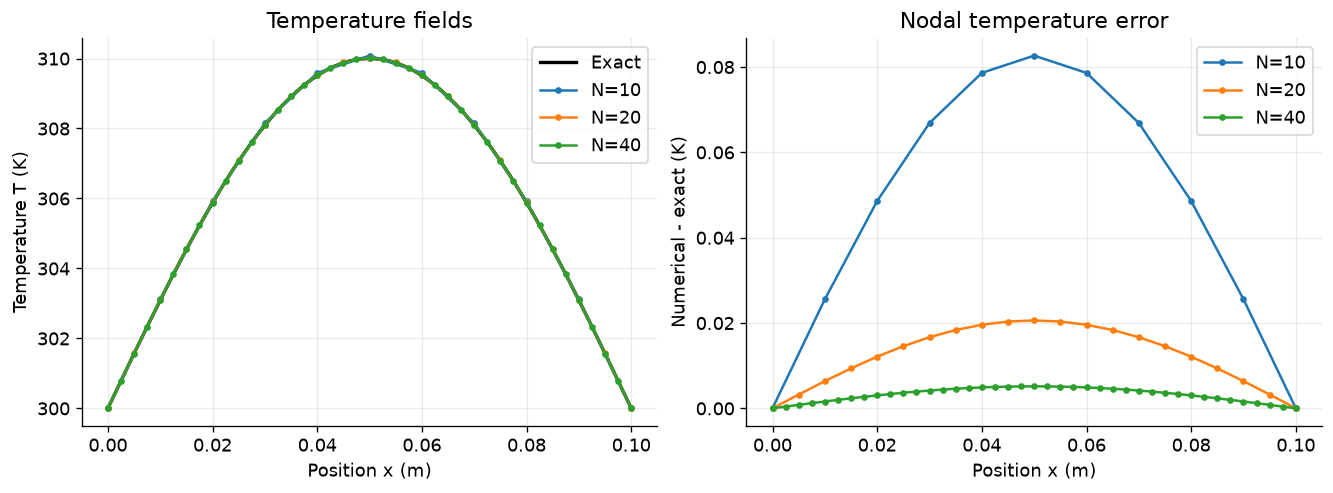

In [5]:
x_exact = np.linspace(0.0, L, 401)
T_exact = exact_temperature(x_exact)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(x_exact, T_exact, color="black", lw=2, label="Exact")
for N in MESHES:
    row = mesh_results[N]
    axes[0].plot(row["x"], row["T"], "o-", ms=3, label=f"N={N}")
    axes[1].plot(row["x"], row["T"] - exact_temperature(row["x"]),
                 "o-", ms=3, label=f"N={N}")
axes[0].set(xlabel="Position x (m)", ylabel="Temperature T (K)",
            title="Temperature fields")
axes[1].set(xlabel="Position x (m)", ylabel="Numerical - exact (K)",
            title="Nodal temperature error")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

## 6. Automatic checks

Check that each mesh includes the shared center node, boundary values stay fixed, the fields are symmetric, and the centerline rise converges monotonically. The Richardson/GCI calculations enforce the stated accuracy targets.

In [6]:
for N in MESHES:
    row = mesh_results[N]
    assert np.isclose(row["x"][N // 2], L / 2)
    assert row["T"][0] == T_LEFT and row["T"][-1] == T_RIGHT
    np.testing.assert_allclose(row["T"], row["T"][::-1], rtol=0, atol=1e-10)

f_values = np.array([mesh_results[N]["f"] for N in MESHES])
center_errors = np.abs(f_values - AMPLITUDE)
assert np.all(np.diff(f_values) < 0), "Expected centerline rise to converge monotonically."
assert np.all(np.diff(center_errors) < 0), "Centerline error should decrease with refinement."


assert 1.9 <= p <= 2.1, "Observed order should be approximately two."
assert abs(f_ext - AMPLITUDE) < 0.001, "Extrapolation missed the accuracy target."
assert np.isfinite(G) and G > 0
# A sine is an eigenvector of this discrete operator: an independent reference.
for N in MESHES:
    eigenvalue_ratio = ((np.pi / N) / (2 * np.sin(np.pi / (2 * N))))**2
    discrete_reference = T_LEFT + AMPLITUDE * eigenvalue_ratio * np.sin(
        np.pi * mesh_results[N]["x"] / L
    )
    np.testing.assert_allclose(mesh_results[N]["T"], discrete_reference,
                               rtol=0, atol=1e-10)
assert G >= fine_exact_error, "The estimate covers the exact error in this example."
print("PASS: mesh alignment, boundaries, symmetry, monotonic convergence, "
      "discrete sine reference, observed order, and extrapolation accuracy.")
print(f"Estimated fine-grid error {G:.8f} K; exact error {fine_exact_error:.8f} K.")

PASS: mesh alignment, boundaries, symmetry, monotonic convergence, discrete sine reference, observed order, and extrapolation accuracy.
Estimated fine-grid error 0.00639585 K; exact error 0.00514200 K.


## 7. Discussion and next steps

### Interpreting the results

The centerline rises decrease toward 10 K as the spacing halves, with errors decreasing by approximately a factor of four. The observed order is approximately 2.0067, consistent with the centered second-order stencil; extrapolation removes most of the leading error and gives approximately 10.000025 K.

On the finest mesh, the exact centerline error is approximately 0.005142 K and the estimated fine-grid error is approximately 0.006396 K. Thus, the estimate is about 1.244 times the exact error in this example. The relative GCI is approximately 0.0006393 (0.06393%), normalized by the **temperature rise**, not by the absolute temperature of approximately 310 K. Changing the normalization changes the percentage, while the dimensional estimate in kelvin stays the same.

### Why the order is close to two

The sampled sine is an eigenvector of the discrete second derivative. With these fixed boundaries, its numerical amplitude is

$$f_N=10\,\mathrm{K}\left[\frac{\pi/N}{2\sin(\pi/(2N))}\right]^2
=10\,\mathrm{K}\left[1+\frac{\pi^2}{12N^2}+O(N^{-4})\right].$$

The leading positive error is proportional to $h^2$, explaining both the slight overprediction and the monotonic decrease. Higher-order terms explain why the three-mesh observed order is slightly above two. This independent discrete solution is also checked against the assembled linear solve.

### Limitations

Richardson extrapolation and this GCI estimate assume systematic refinement and a dominant power-law error; coarse meshes, oscillatory convergence, or mesh differences near roundoff can undermine that assumption. The safety factor does not assign a statistical coverage probability or include physical-model, input, or unfinished-solver errors, so GCI is not a guaranteed confidence interval.

Three results alone do not prove that the asymptotic regime has been reached. In particular, a ratio constructed from these same differences and this fitted $p$ is not an independent validation; the exact solution and the discrete sine reference provide stronger evidence here.

### Scope and extension

This is a smooth, one-dimensional, constant-conductivity manufactured problem on uniform meshes. Add $N=80$ as an independent refinement, recompute the estimate with $(20,40,80)$, and compare the observed order and extrapolation error. For a physical problem without an exact solution, also verify that solver errors are small compared with mesh differences and keep modeling and input uncertainties separate.

### Reading

The [NASA grid-convergence tutorial](https://www.grc.nasa.gov/www/wind/valid/tutorial/spatconv.html) describes Richardson extrapolation, the asymptotic range, and GCI, including the recommended safety factor of 1.25 for studies with at least three grids. For background on separating numerical error from physical-model error, revisit the [previous notebook](20260930-solver-error.ipynb).